# Path Finder Notebook

This project is working with tensorflow and keras to implement a deep Q-learning algorithm to find the optimal path through a maze. The maze is represented as a grid, where the agent can move in four directions: left, right, up, and down. The goal of the agent is to find the optimal path to reach the agent while maximizing the reward.

In [13]:
from __future__ import print_function
import random
import os
import time
import numpy as np
import matplotlib.pyplot as plt
from keras.models import load_model
from datetime import datetime
from keras import Input
from keras.models import Sequential
from keras.layers import Dense, Dropout, PReLU
from keras.regularizers import l2
from Maze import Maze
from GameExperience import GameExperience
from HelperFunctions import version

MODEL_NAME = "Path_Finder"
NEW_MODEL_VERSION, MODEL_VERSION = version(1, MODEL_NAME)
CONTINUE_TRAINING = True

%matplotlib inline

The following code block contains a 8x8 matrix that will be used as a maze object. The value of 1 represents a free cell, while the value of 0 represents a wall. The agent will start in the top-left corner and the goal is located in the bottom-right corner. The agent's goal is to find the optimal path to reach the bottom right while maximizing the reward.

In [14]:
maze = np.array([
    [ 1.,  0.,  1.,  1.,  1.,  1.,  1.,  1.],
    [ 1.,  0.,  1.,  1.,  1.,  0.,  1.,  1.],
    [ 1.,  1.,  1.,  1.,  0.,  1.,  0.,  1.],
    [ 1.,  1.,  1.,  0.,  1.,  1.,  1.,  1.],
    [ 1.,  1.,  0.,  1.,  1.,  1.,  1.,  1.],
    [ 1.,  1.,  1.,  0.,  1.,  0.,  0.,  0.],
    [ 1.,  1.,  1.,  0.,  1.,  1.,  1.,  1.],
    [ 1.,  1.,  1.,  1.,  0.,  1.,  1.,  1.]
])

This helper function allows a visual representation of the maze object and the agent's position within the maze. The free cells are represented in white, while the walls are represented in black. The agent's position is represented in gray, and the target is represented in light gray.

In [15]:
def show(qmaze):
    plt.grid(True)
    nrows, ncols = qmaze.maze.shape
    ax = plt.gca()
    ax.set_xticks(np.arange(0.5, nrows, 1))
    ax.set_yticks(np.arange(0.5, ncols, 1))
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    np_canvas = np.copy(qmaze.maze)
    for row,col in qmaze.visited:
        np_canvas[row,col] = 0.6
    agent_row, agent_col, _ = qmaze.state
    np_canvas[agent_row, agent_col] = 0.3   # agent cell
    np_canvas[nrows-1, ncols-1] = 0.9 # goal cell
    img = plt.imshow(np_canvas, interpolation='none', cmap='gray')
    return img

The following code block defines the action space for the agent. The agent can move in four directions: left, up, right, and down. Each action is represented by an integer value, which will be used to determine the next state of the environment after the agent takes an action.

In [16]:
LEFT = 0
UP = 1
RIGHT = 2
DOWN = 3


# Exploration factor
epsilon = 1.0

# Actions dictionary
actions_dict = {
    LEFT: 'left',
    UP: 'up',
    RIGHT: 'right',
    DOWN: 'down',
}

num_actions = len(actions_dict)


The sample code block and output below show creating a maze object and performing one action (DOWN), which returns the reward. The resulting updated environment is visualized. This is just a test to show the environment is working as expected.

reward= -0.04


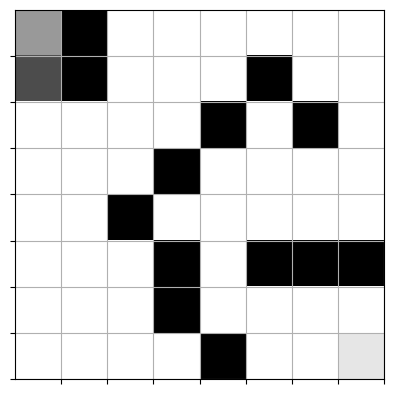

In [17]:
q_maze = Maze(maze)
canvas, reward, game_over = q_maze.act(DOWN)
print("reward=", reward)
show(q_maze)

This function simulates a full game based on the provided trained model. The other parameters include the Maze object and the starting position of the agent.

In [18]:
def play_game(pg_model, pg_q_maze, agent_cell):
    pg_q_maze.reset(agent_cell)
    env_state = pg_q_maze.observe()
    while True:
        prev_env_state = env_state
        # get next action, batching to avoid verbose and batch command still accepts a single env state.
        q = pg_model.predict_on_batch(prev_env_state)

        """
        # Mask the invalid actions
        valid = pg_q_maze.valid_actions()
        if not valid:
            raise Exception("Invalid action taken. Check maze layout.")
        else:
            masked = np.full_like(q[0], -np.inf, dtype=float)
            for a in valid:
                masked[a] = q[0][a]
            action = int(np.argmax(masked))
        """
        action = np.argmax(q[0])

        # apply action, get rewards and new state
        env_state, pg_reward, game_status = pg_q_maze.act(action)
        if game_status == 'win':
            return True, pg_q_maze
        elif game_status == 'lose':
            return False, pg_q_maze

This function helps you to determine whether the agebt can win any game at all. If your maze is not well-designed, the agent may not win any game at all. In this case, your training would not yield any result. The provided maze in this notebook ensures that there is a path to win, and you can run this method to check.

In [19]:
def completion_check(cc_model, cc_q_maze):
    for cell in cc_q_maze.free_cells:
        if not cc_q_maze.valid_actions(cell):
            return False
        if not play_game(cc_model, cc_q_maze, cell):
            return False
    return True

The code you have been given in this block will build the neural network model. Note the number of layers, as well as the activation, optimizer, and loss functions that are used to train the model.

In [20]:
def build_model(bm_maze):

    #Model Init and input layer matching the size of maze grid
    bm_model = Sequential()
    bm_model.add(Input(shape=(bm_maze.size,)))

    # Hidden Layer One
    bm_model.add(Dense(bm_maze.size, kernel_regularizer=l2(0.01)))
    bm_model.add(PReLU())
    bm_model.add(Dropout(0.2))

    # Hidden Layer Two
    bm_model.add(Dense(bm_maze.size))
    bm_model.add(PReLU())
    bm_model.add(Dropout(0.2))

    # Output Layer matching number of actions
    bm_model.add(Dense(num_actions))
    bm_model.compile(optimizer='adam', loss='mse')
    return bm_model

# Complete the Q-Training Algorithm Code Block

This is your deep Q-learning implementation. The goal of your deep Q-learning implementation is to find the best possible navigation sequence that results in reaching the Target cell while maximizing the reward. In your implementation, you need to determine the optimal number of epochs to achieve a 100% win rate.

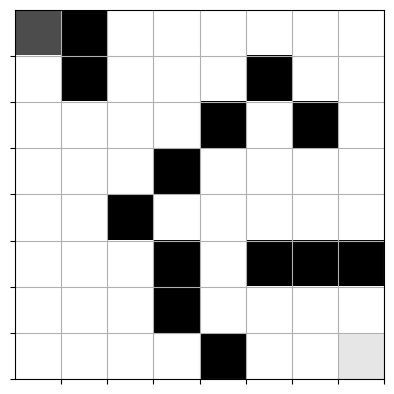

In [21]:
q_maze = Maze(maze)
show(q_maze)

In [22]:
def q_train(qt_model, qt_maze, **opt):

    # exploration factor
    global epsilon

    # Epsilon Decay
    epsilon_decay = opt.get('epsilon_decay', 0.995) # Reduce by 0.05% per epoch by default

    # number of epochs
    n_epoch = opt.get('epochs', 15000)

    # maximum memory to store episodes
    max_memory = opt.get('max_memory', 1000)

    # maximum data size for training
    data_size = opt.get('data_size', 50)

    # File path
    file_path = opt.get('fp', None)

    # start time
    start_time = datetime.now()

    # Construct environment/game from numpy array: maze (see above)
    qt_q_maze = Maze(qt_maze)

    # Initialize experience replay object
    experience = GameExperience(qt_model, max_memory=max_memory)
    win_history = []   # history of win/lose game
    hsize = qt_q_maze.maze.size // 2   # history window size
    epoch = 0

    # For each epoch:
    for epoch in range(n_epoch):
        #Agent_cell = randomly select a free cell
        agent_cell = random.choice(qt_q_maze.free_cells)

        #Reset the maze with agent set to above position
        qt_q_maze.reset(agent_cell)

        #envstate = Environment.current_state
        env_state = qt_q_maze.observe()
        loss = 0.0
        n_episodes = 0
        game_status = 'not_over'

        #While state is not game over:
        while game_status == 'not_over':
            previous_env_state = env_state

            #randomly choose action (left, right, up, down) either by exploration or by exploitation
            if np.random.rand() < epsilon:
                #Exploration
                action = np.random.choice(qt_q_maze.valid_actions())
            else:
                #Exploitation
                q_values = qt_model.predict_on_batch(previous_env_state)
                action = np.argmax(q_values[0])

            # Apply the action to get reward, next state, and game status
            env_state, reward_act, game_status = qt_q_maze.act(action)
            n_episodes += 1
            episode = [previous_env_state, action, reward_act, env_state, game_status]

            # Append the win/lose to win_history
            if game_status == 'win':
                win_history.append(1)
            elif game_status == 'lose':
                win_history.append(0)

            #Store episode in Experience replay object
            experience.remember(episode)

            #Train neural network model and evaluate loss
            data = experience.get_data(data_size=data_size)

            #If data is not empty
            if data:
                inputs, targets = data
                qt_model.fit(inputs, targets, epochs=10, batch_size=20, verbose=0)
                loss = qt_model.evaluate(inputs, targets, verbose=0)


        #Print the epoch, loss, episodes, win count, and win rate for each epoch
        dt = datetime.now() - start_time
        t = format_time(dt.total_seconds())
        win_rate = sum(win_history[-hsize:]) / hsize
        template = "Episode: {:03d}/{:d} | Loss: {:.4f} | Step: {:d} | Win count: {:d} | Win rate: {:.3f} | time: {}"
        print(template.format(epoch+1, n_epoch, loss, n_episodes, sum(win_history), win_rate, t))

        # Epsilon decay is applied after each epoch. This decay factor is multiplied by epsilon
        # to decrease it by 0.5% but not below 0.05.
        epsilon = max(0.05, epsilon * epsilon_decay) # decrease epsilon

        #If the win rate is above the threshold and your model passes the completion check, that would be your epoch.
        if sum(win_history[-hsize:]) == hsize and completion_check(qt_model, qt_q_maze):
            print("Reached 100%% win rate at epoch: %d" % (epoch + 1,))
            break

        # Save model every tenth training iteration
        if CONTINUE_TRAINING and (epoch + 1) % 10 == 0:
            file_name = '{model_name}_{model_version}.keras'.format(model_name=MODEL_NAME, model_version=NEW_MODEL_VERSION)
            file_path = os.path.join(os.getcwd(), file_name)
            print("Saved Model: {model_name} version {model_version}".format(model_name=MODEL_NAME, model_version=NEW_MODEL_VERSION))
            model.save(file_path)

    # Determine the total time for training
    dt = datetime.now() - start_time
    seconds = dt.total_seconds()
    t = format_time(seconds)

    print("Number of Epochs: %d, max_mem: %d, data: %d, time: %s" % (epoch + 1, max_memory, data_size, t))
    return seconds

# This is a small utility for printing readable time strings:
def format_time(seconds):
    if seconds < 400:
        s = float(seconds)
        return "%.1f seconds" % (s,)
    elif seconds < 4000:
        m = seconds / 60.0
        return "%.2f minutes" % (m,)
    else:
        h = seconds / 3600.0
        return "%.2f hours" % (h,)

In the next code block, you will build your model and train it using deep Q-learning. Note: This step takes several minutes to fully run.

In [23]:
# Format the file name for the model
file_name = '{model_name}_{model_version}.keras'.format(model_name=MODEL_NAME, model_version=MODEL_VERSION)
file_path = os.path.join(os.getcwd(), file_name)

# Load the model
if os.path.exists(file_path):
    model = load_model(file_path)
    print("Loaded Model: {model} version {version}".format(model=MODEL_NAME, version=MODEL_VERSION))
else:
    model = build_model(maze)
    print("Built Model: {model} version {version}".format(model=MODEL_NAME, version=MODEL_VERSION))

# Train
if CONTINUE_TRAINING:
    q_train(model, maze, epochs=10, max_memory=8 * maze.size, data_size=32, fp=file_path)

# Save model
time.sleep(1)
if CONTINUE_TRAINING:
    file_name = '{model_name}_{model_version}.keras'.format(model_name=MODEL_NAME, model_version=NEW_MODEL_VERSION)
    file_path = os.path.join(os.getcwd(), file_name)
    print("Saved Model: {model_name} version {model_version}".format(model_name=MODEL_NAME, model_version=NEW_MODEL_VERSION))
    model.save(file_path)

Loaded Model: Path_Finder version 1.0
Episode: 001/10 | Loss: 0.0006 | Step: 143 | Win count: 0 | Win rate: 0.000 | time: 54.9 seconds
Episode: 002/10 | Loss: 0.0010 | Step: 147 | Win count: 0 | Win rate: 0.000 | time: 114.4 seconds
Episode: 003/10 | Loss: 0.0015 | Step: 150 | Win count: 0 | Win rate: 0.000 | time: 173.3 seconds
Episode: 004/10 | Loss: 0.0019 | Step: 152 | Win count: 0 | Win rate: 0.000 | time: 229.8 seconds
Episode: 005/10 | Loss: 0.0012 | Step: 145 | Win count: 0 | Win rate: 0.000 | time: 277.4 seconds
Episode: 006/10 | Loss: 0.0017 | Step: 149 | Win count: 0 | Win rate: 0.000 | time: 326.5 seconds
Episode: 007/10 | Loss: 0.0015 | Step: 109 | Win count: 1 | Win rate: 0.031 | time: 362.6 seconds
Episode: 008/10 | Loss: 0.0124 | Step: 9 | Win count: 2 | Win rate: 0.062 | time: 365.6 seconds
Episode: 009/10 | Loss: 0.0130 | Step: 150 | Win count: 2 | Win rate: 0.062 | time: 6.93 minutes
Episode: 010/10 | Loss: 0.0011 | Step: 143 | Win count: 2 | Win rate: 0.062 | time: 

This cell will check to see if the model passes the completion check. Note: This could take several minutes.

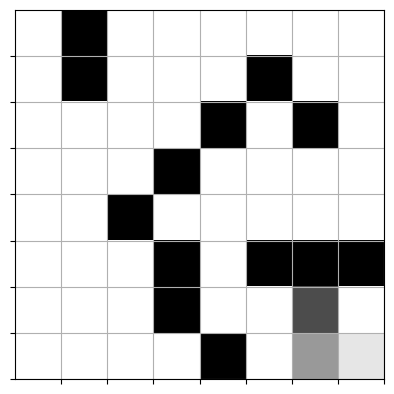

In [24]:
completion_check(model, q_maze)
show(q_maze)

This cell will test your model for one game. It will start the agent in the top-left corner and run play_game. The agent should find a path from the starting position to the target. The target is located in the bottom-right corner.

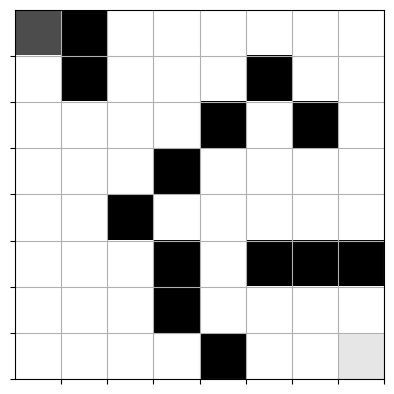

In [25]:
agent_start = (0, 0)
status, q_maze = play_game(model, q_maze, agent_start)
show(q_maze)